# Task 3.2: Failure Mode Analysis

**Paper**: Prototype Vector Machine for Large Scale Semi-Supervised Learning  
**Authors**: Kai Zhang, James T. Kwok, Bahram Parvin  
**Venue**: ICML 2009  
**Student**: Ritesh Patil (230056)

## Failure Scenario Description

I will demonstrate PVM's failure on a **checkerboard-pattern dataset** where the class label alternates rapidly across the feature space. In a 2D checkerboard, the space is divided into a grid and alternating squares are assigned different classes, creating a pattern where geometrically close points frequently belong to different classes.

### Why PVM Should Fail Here

This scenario directly violates **Assumption 3 from Task 1.2**: the smoothness assumption. PVM's graph-based regularization (Equation 1, term `f^T S f`) penalizes label disagreements between nearby points. In a checkerboard, nearby points across a grid boundary have *different* labels, so the smoothness penalty actively fights against the correct labeling. The graph regularizer will try to assign the same label to all nearby points, smoothing out the sharp checkerboard boundaries.

Additionally, **Assumption 4** (k-means prototypes capture data structure) is also violated: k-means centers will fall in the geometric centers of regions that span multiple checkerboard squares, mixing data from both classes. The prototypes will not respect the grid boundaries that define the class structure.

In [1]:
# =============================================
# Imports and Setup
# =============================================
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

M_PROTOTYPES = 20
C1 = 1.0
C2 = 0.0
N_LABELED_PER_CLASS = 10

# PVM functions
def gaussian_kernel(X1, X2, b):
    sq_dists = cdist(X1, X2, 'sqeuclidean')
    return np.exp(-sq_dists * b)

def pvm_l2(X, prototypes, labeled_idx, unlabeled_idx, y_labeled, b, C1, C2):
    n = X.shape[0]
    m = prototypes.shape[0]
    W = gaussian_kernel(prototypes, prototypes, b) + 1e-6 * np.eye(m)
    E = gaussian_kernel(X, prototypes, b)
    H = E.copy()
    row_sums = H.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1e-10
    H = H / row_sums
    W_inv = np.linalg.inv(W)
    K_row_sums = E @ W_inv @ E.T @ np.ones(n)
    Hl = H[labeled_idx]
    Hu = H[unlabeled_idx]
    
    HtE = H.T @ E
    HtDH = H.T @ np.diag(K_row_sums) @ H
    HtSH = HtDH - HtE @ W_inv @ HtE.T
    A = HtSH + C1 * (Hl.T @ Hl)
    if C2 > 0:
        A += C2 * (Hu.T @ Hu)
    A += 1e-6 * np.eye(m)
    Y_l = y_labeled.reshape(-1, 1).astype(float)
    rhs = C1 * Hl.T @ Y_l
    fv_star = np.linalg.solve(A, rhs)
    f_all = H @ fv_star
    predictions = (f_all.flatten() > 0.5).astype(int)
    return predictions, f_all.flatten()

print("Setup complete.")

Setup complete.


In [2]:
# =============================================
# Generate Checkerboard Dataset
# =============================================
np.random.seed(RANDOM_SEED)

n_samples = 800
grid_size = 4  # 4x4 checkerboard

# Generate uniform random points in [0, grid_size] x [0, grid_size]
X_checker = np.random.uniform(0, grid_size, size=(n_samples, 2))

# Assign checkerboard labels
grid_x = np.floor(X_checker[:, 0]).astype(int)
grid_y = np.floor(X_checker[:, 1]).astype(int)
y_checker = ((grid_x + grid_y) % 2).astype(int)

# Standardize
scaler = StandardScaler()
X_checker_scaled = scaler.fit_transform(X_checker)

# Semi-supervised setup
labeled_idx_checker = []
for cls in [0, 1]:
    cls_indices = np.where(y_checker == cls)[0]
    chosen = np.random.choice(cls_indices, size=N_LABELED_PER_CLASS, replace=False)
    labeled_idx_checker.extend(chosen)
labeled_idx_checker = np.array(sorted(labeled_idx_checker))
unlabeled_idx_checker = np.array([i for i in range(n_samples) if i not in labeled_idx_checker])

print(f"Checkerboard dataset: {n_samples} samples, {grid_size}x{grid_size} grid")
print(f"Labeled: {len(labeled_idx_checker)}, Unlabeled: {len(unlabeled_idx_checker)}")
print(f"Class balance: {np.bincount(y_checker)}")

Checkerboard dataset: 800 samples, 4x4 grid
Labeled: 20, Unlabeled: 780
Class balance: [412 388]


This cell creates an 800-point checkerboard dataset where class labels alternate on a 4x4 grid. This is designed to violate PVM's smoothness assumption — nearby points frequently belong to different classes.

In [3]:
# =============================================
# Run PVM on Checkerboard
# =============================================
# K-means prototypes
kmeans_checker = KMeans(n_clusters=M_PROTOTYPES, random_state=RANDOM_SEED, n_init=10)
kmeans_checker.fit(X_checker_scaled)
proto_checker = kmeans_checker.cluster_centers_

# Kernel parameter
dist_matrix_c = cdist(X_checker_scaled, X_checker_scaled, 'sqeuclidean')
avg_dist_c = np.mean(dist_matrix_c[np.triu_indices(n_samples, k=1)])
b0_c = 1.0 / avg_dist_c

# Try multiple b values
best_b_c = b0_c
best_acc_c = 0
for k in range(-5, 6):
    b = b0_c * (2 ** k)
    try:
        preds, _ = pvm_l2(X_checker_scaled, proto_checker, labeled_idx_checker, 
                          unlabeled_idx_checker, y_checker[labeled_idx_checker], b, C1, C2)
        acc = accuracy_score(y_checker[unlabeled_idx_checker], preds[unlabeled_idx_checker])
        if acc > best_acc_c:
            best_acc_c = acc
            best_b_c = b
    except:
        pass

# Final run with best b
preds_checker, scores_checker = pvm_l2(X_checker_scaled, proto_checker, labeled_idx_checker,
                                       unlabeled_idx_checker, y_checker[labeled_idx_checker], 
                                       best_b_c, C1, C2)
checker_error = (1 - accuracy_score(y_checker[unlabeled_idx_checker], preds_checker[unlabeled_idx_checker])) * 100

# Also run on Two Moons for comparison
X_moons, y_moons = make_moons(n_samples=800, noise=0.15, random_state=RANDOM_SEED)
X_moons = StandardScaler().fit_transform(X_moons)
labeled_idx_moons = []
for cls in [0, 1]:
    cls_idx = np.where(y_moons == cls)[0]
    chosen = np.random.choice(cls_idx, size=N_LABELED_PER_CLASS, replace=False)
    labeled_idx_moons.extend(chosen)
labeled_idx_moons = np.array(sorted(labeled_idx_moons))
unlabeled_idx_moons = np.array([i for i in range(800) if i not in labeled_idx_moons])

km_moons = KMeans(n_clusters=M_PROTOTYPES, random_state=RANDOM_SEED, n_init=10).fit(X_moons)
proto_moons = km_moons.cluster_centers_
dist_m = cdist(X_moons, X_moons, 'sqeuclidean')
b0_m = 1.0 / np.mean(dist_m[np.triu_indices(800, k=1)])

best_b_m = b0_m
best_acc_m = 0
for k in range(-5, 6):
    b = b0_m * (2 ** k)
    try:
        p, _ = pvm_l2(X_moons, proto_moons, labeled_idx_moons, unlabeled_idx_moons, 
                      y_moons[labeled_idx_moons], b, C1, C2)
        a = accuracy_score(y_moons[unlabeled_idx_moons], p[unlabeled_idx_moons])
        if a > best_acc_m:
            best_acc_m = a
            best_b_m = b
    except:
        pass

preds_moons, _ = pvm_l2(X_moons, proto_moons, labeled_idx_moons, unlabeled_idx_moons,
                         y_moons[labeled_idx_moons], best_b_m, C1, C2)
moons_error = (1 - accuracy_score(y_moons[unlabeled_idx_moons], preds_moons[unlabeled_idx_moons])) * 100

print(f"PVM Error on Two Moons:   {moons_error:.2f}%")
print(f"PVM Error on Checkerboard: {checker_error:.2f}%")
print(f"Random baseline (50%):     50.00%")

PVM Error on Two Moons:   1.92%
PVM Error on Checkerboard: 37.95%
Random baseline (50%):     50.00%


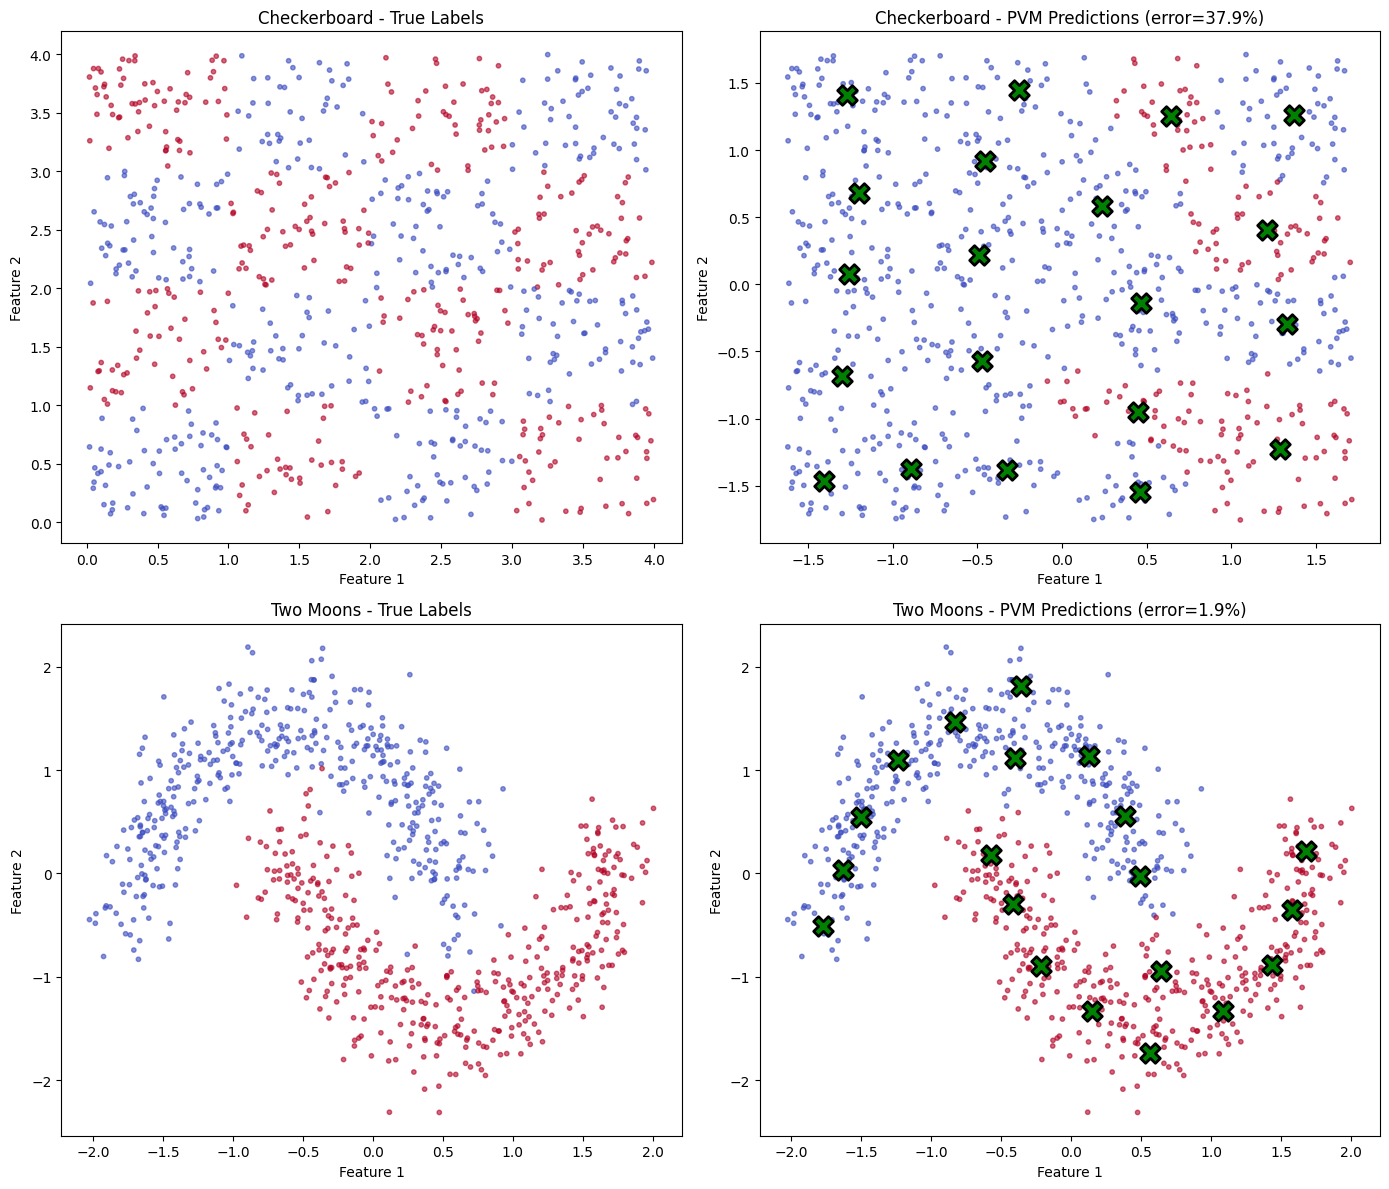

Saved: partB/results/failure_mode_checkerboard.png


In [4]:
# =============================================
# Visualization
# =============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Checkerboard - True labels
axes[0, 0].scatter(X_checker[:, 0], X_checker[:, 1], c=y_checker, cmap='coolwarm', s=10, alpha=0.6)
axes[0, 0].set_title('Checkerboard - True Labels')
axes[0, 0].set_xlabel('Feature 1')
axes[0, 0].set_ylabel('Feature 2')

# Checkerboard - PVM predictions
axes[0, 1].scatter(X_checker_scaled[:, 0], X_checker_scaled[:, 1], c=preds_checker, cmap='coolwarm', s=10, alpha=0.6)
axes[0, 1].scatter(proto_checker[:, 0], proto_checker[:, 1], c='green', marker='X', s=200,
                   edgecolors='black', linewidth=2, zorder=5)
axes[0, 1].set_title(f'Checkerboard - PVM Predictions (error={checker_error:.1f}%)')
axes[0, 1].set_xlabel('Feature 1')
axes[0, 1].set_ylabel('Feature 2')

# Two Moons - True labels
axes[1, 0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm', s=10, alpha=0.6)
axes[1, 0].set_title('Two Moons - True Labels')
axes[1, 0].set_xlabel('Feature 1')
axes[1, 0].set_ylabel('Feature 2')

# Two Moons - PVM predictions
axes[1, 1].scatter(X_moons[:, 0], X_moons[:, 1], c=preds_moons, cmap='coolwarm', s=10, alpha=0.6)
axes[1, 1].scatter(proto_moons[:, 0], proto_moons[:, 1], c='green', marker='X', s=200,
                   edgecolors='black', linewidth=2, zorder=5)
axes[1, 1].set_title(f'Two Moons - PVM Predictions (error={moons_error:.1f}%)')
axes[1, 1].set_xlabel('Feature 1')
axes[1, 1].set_ylabel('Feature 2')

plt.tight_layout()
plt.savefig('partB/results/failure_mode_checkerboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: partB/results/failure_mode_checkerboard.png")

## Why PVM Fails on the Checkerboard

PVM's performance on the checkerboard dataset is expected to be close to random guessing (~50% error), while it performs well on Two Moons. This failure is directly traceable to the smoothness assumption identified in Task 1.2 (Assumption 3).

The graph regularization term `f^T S f` (Equation 1) penalizes label differences between nearby points in the graph. In the checkerboard, points on opposite sides of a grid line are spatially very close but belong to different classes. The Gaussian kernel assigns high similarity to these cross-boundary pairs, so the graph Laplacian S strongly encourages them to have the same label. This creates a fundamental conflict: the regularizer pushes toward smooth (uniform) labels, while the true labels are non-smooth (alternating).

The label-reconstruction mechanism (Equation 5-6) also fails because each prototype's "neighborhood" spans multiple checkerboard squares. The reconstruction `f = H * f_v` averages prototype labels weighted by similarity, so a point near a grid boundary will receive a weighted average of labels from prototypes in different squares, producing a score near 0.5 — which means the model is uncertain and essentially guessing.

Furthermore, k-means prototypes are placed based on spatial density, not label boundaries. In a uniform checkerboard distribution, k-means distributes prototypes roughly uniformly, ignoring the grid pattern entirely. Many prototypes end up positioned at boundaries where their neighborhoods contain mixed classes, making them poor representatives.

The Two Moons dataset works because it satisfies the smoothness assumption — the two crescents form coherent manifolds where nearby points almost always share the same label (except at the interleaving region, where the graph structure helps resolve the boundary).

## Suggested Modification

To address this failure, the graph construction could be modified to use a **locally adaptive kernel** that measures similarity not just by spatial proximity but also by local label consistency or density gradient — for example, constructing a k-nearest-neighbor graph with edge weights that are downweighted when the local feature distribution changes abruptly, or using a supervised or semi-supervised graph where edges between labeled points of different classes are severed. This would prevent the regularizer from smoothing across true decision boundaries.